**<h1>San Diego Participant List**
#### Supporting Analysis
<i>Any question regarding the notebook, please contact Robert Ford<br>
    Last Updated: 11/19/2025</i>
* Participant list graphics and counts 
* Started development on 11/19/2025
* Finished Iteration on -11/19/2025-

In [2]:
# ...existing code...
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [5]:
# --- CONFIG: update this to your spreadsheet ---
excel_path = r"C:/Users/Rford/OneDrive - California Energy Commission/Documents/Analysis - Scripts and Code/AHJ-Database/data/raw/San_Diego_Energy_Code_Forum_Attendees_2956870869571_20251119_170828_005.xlsx"
sheet_name = 0  # or the sheet name

# --- load and clean ---
df = pd.read_excel(excel_path, sheet_name=sheet_name)
df.columns = df.columns.str.strip()  # trim whitespace in column names


In [6]:
# ensure columns exist
for col in ["Purchaser city", "Purchaser state", "Purchaser country"]:
    if col not in df.columns:
        raise KeyError(f"Column not found: {col}")

# basic cleaning
df["Purchaser city"] = df["Purchaser city"].fillna("Unknown").astype(str).str.strip()
df["Purchaser state"] = df["Purchaser state"].fillna("Unknown").astype(str).str.strip()
df["Purchaser country"] = df["Purchaser country"].fillna("Unknown").astype(str).str.strip()

# --- compute counts ---
top_n = 20
city_counts = df["Purchaser city"].value_counts().head(top_n)
state_counts = df["Purchaser state"].value_counts()
country_counts = df["Purchaser country"].value_counts()

C:\Users\Rford\AppData\Local\Temp\ipykernel_10488\2877913278.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.values, y=city_counts.index, palette="viridis")


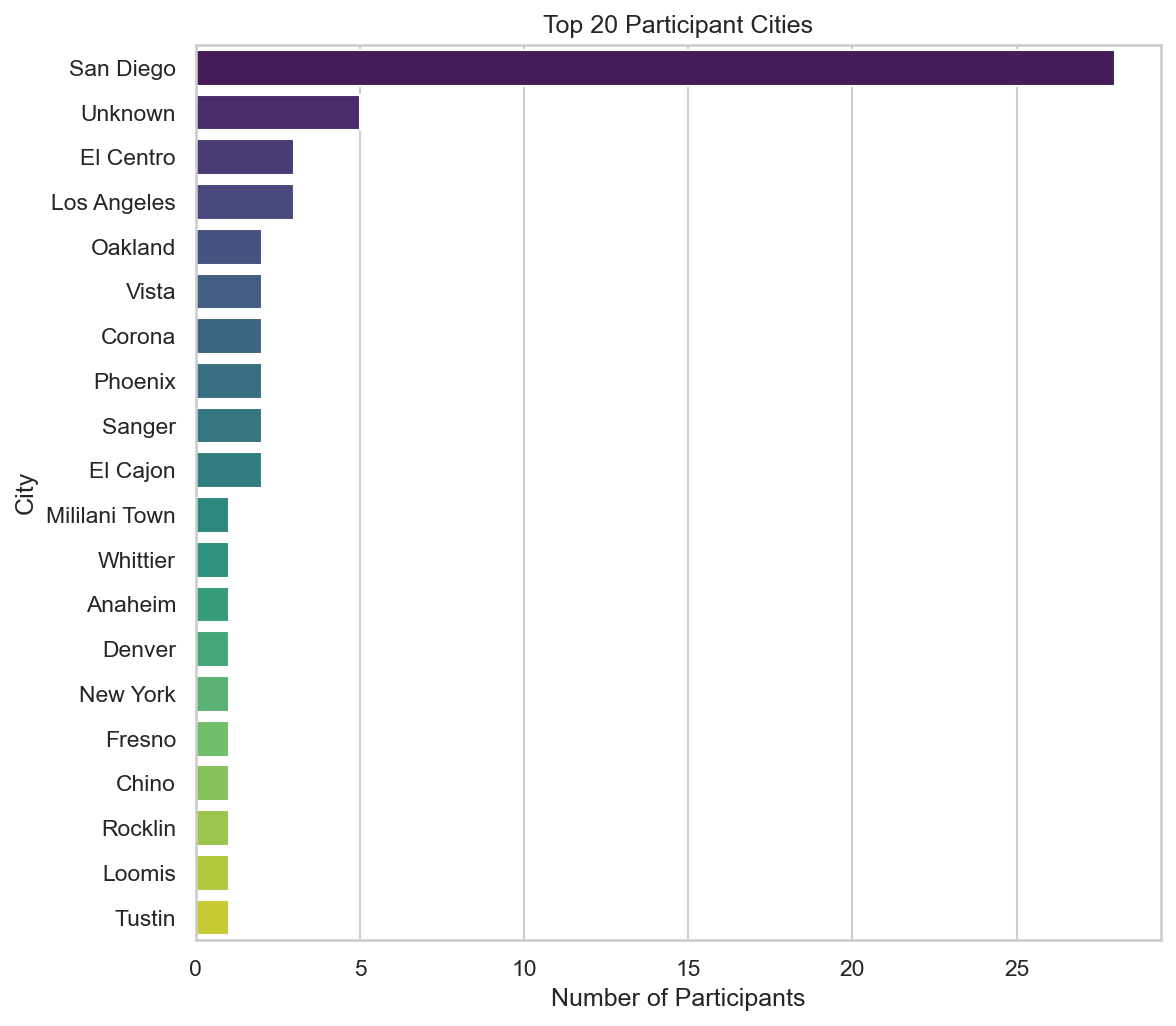

C:\Users\Rford\AppData\Local\Temp\ipykernel_10488\2877913278.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_counts.values, y=state_counts.index, palette="magma")


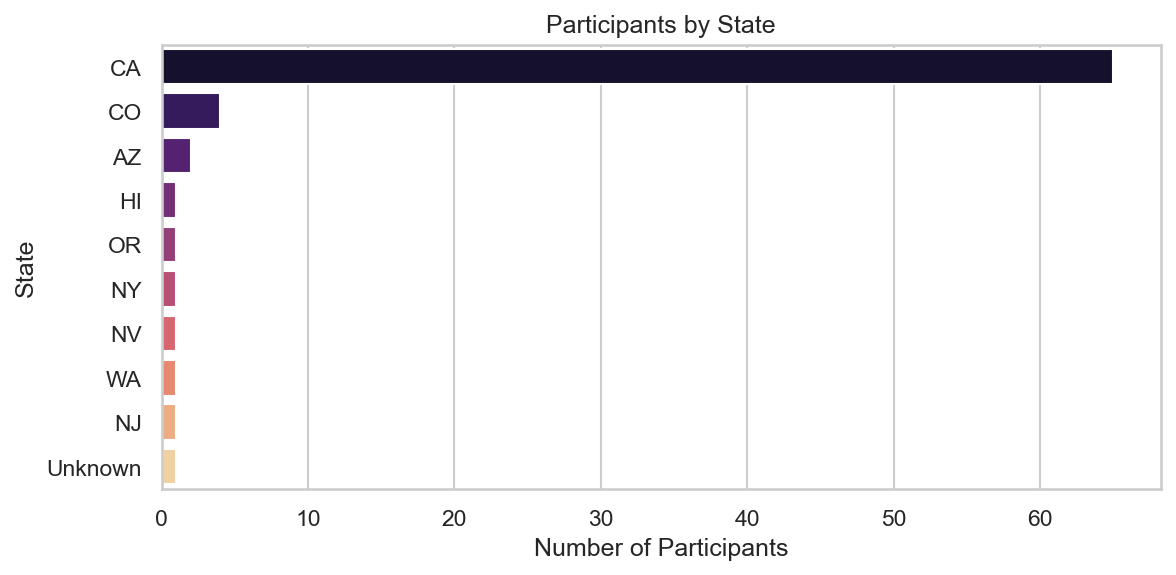


Top cities:
Purchaser city
San Diego        28
Unknown           5
El Centro         3
Los Angeles       3
Oakland           2
Vista             2
Corona            2
Phoenix           2
Sanger            2
El Cajon          2
Mililani Town     1
Whittier          1
Anaheim           1
Denver            1
New York          1
Fresno            1
Chino             1
Rocklin           1
Loomis            1
Tustin            1

States summary (top 20):
Purchaser state
CA         65
CO          4
AZ          2
HI          1
OR          1
NY          1
NV          1
WA          1
NJ          1
Unknown     1

Countries summary:
Purchaser country
US         77
Unknown     1


In [8]:
# create output folder for figures
out_dir = "figures_participants"
os.makedirs(out_dir, exist_ok=True)

sns.set(style="whitegrid", rc={"figure.dpi": 150})

# --- plot top cities (horizontal bar) ---
plt.figure(figsize=(8, max(4, 0.35 * len(city_counts))))
sns.barplot(x=city_counts.values, y=city_counts.index, palette="viridis")
plt.title(f"Top {len(city_counts)} Participant Cities")
plt.xlabel("Number of Participants")
plt.ylabel("City")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "top_cities.png"))
plt.show()

# --- plot states (vertical bar) ---
plt.figure(figsize=(8, max(4, 0.2 * len(state_counts))))
sns.barplot(x=state_counts.values, y=state_counts.index, palette="magma")
plt.title("Participants by State")
plt.xlabel("Number of Participants")
plt.ylabel("State")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "by_state.png"))
plt.show()

# --- print quick tables ---
print("\nTop cities:")
print(city_counts.to_string())

print("\nStates summary (top 20):")
print(state_counts.head(20).to_string())

print("\nCountries summary:")
print(country_counts.to_string())
